<div style="text-align:center; padding:18px 0 6px 0"></div>

<div style="text-align:center; color:#8b949e; font-size:12px; padding-bottom:8px">Copyright © QPerfect &middot; Released under the MIT License &middot; <a href="https://qperfect.io">qperfect.io</a></div>

---

# The `strasbourg` module — places, distances, and plotting

A walkthrough of `strasbourg_markets_demo.strasbourg`: the canonical
data on Strasbourg's 11 Christmas markets, 14 monuments, and the Gare
Centrale, with WGS-84 geodesic distances (geopy / Karney) and a
matplotlib plotter that can optionally overlay an OSM basemap.

The module's design rationale is in `notes/00-context.md` and
`notes/05-aymane-draft-status.md`.

In [1]:
import matplotlib.pyplot as plt
from strasbourg_markets_demo import strasbourg as s, theme
theme.apply()


## The `Place` dataclass

In [2]:
kleber = s.find("kleber")
print(kleber)
print()
print(f"kleber.name = {kleber.name}")
print(f"kleber.coord = {kleber.coord}")
print(f"kleber.kind = {kleber.kind}")
print(f"kleber.color = {kleber.color}    # also used in the theme palette")
print(f"kleber.aliases = {kleber.aliases}")


Place(key='kleber', name='Place Kléber', lat=48.58331, lon=7.74596, kind='market', emoji='🎄', color='#ff4757', description='Grand Sapin (30 m), ice rink, 130+ stands. Christkindelsmärik historique.', aliases=('Kléber', 'Place Kleber'))

kleber.name = Place Kléber
kleber.coord = (48.58331, 7.74596)
kleber.kind = market
kleber.color = #ff4757    # also used in the theme palette
kleber.aliases = ('Kléber', 'Place Kleber')


## Looking up places

In [3]:
# All four queries below resolve to the same Place — case- and accent-insensitive.
for query in ["kleber", "Place Kléber", "PLACE KLEBER", "Kléber"]:
    p = s.find(query)
    print(f"{query!r:30s} -> {p.name}")
print()
print(f"{len(s.MARKETS)} markets, {len(s.MONUMENTS)} monuments, {len(s.TRANSPORT)} transport")
print()
print("first three monuments:")
for p in s.by_kind('monument')[:3]:
    print(f"  {p.key:25s} {p.name}")


'kleber'                       -> Place Kléber
'Place Kléber'                 -> Place Kléber
'PLACE KLEBER'                 -> Place Kléber
'Kléber'                       -> Place Kléber

11 markets, 14 monuments, 1 transport

first three monuments:
  cathedrale_notre_dame     Cathédrale Notre-Dame de Strasbourg
  palais_rohan              Palais des Rohan
  maison_kammerzell         Maison Kammerzell


## Distances

In [4]:
print(f"distance Kléber - Broglie    : {s.distance_m('kleber', 'broglie'):8.2f} m")
print(f"distance Kléber - Cathedrale : {s.distance_m('kleber', 'cathedrale_market'):8.2f} m")

# Pairwise matrix on a chosen subset.
five = s.tsp_five()
D = s.distance_matrix_m(five)
print(f"""
pairwise distance matrix (m), {len(five)} markets:
{D}""")


distance Kléber - Broglie    :   371.99 m
distance Kléber - Cathedrale :   365.92 m

pairwise distance matrix (m), 5 markets:
[[  0.         371.99063655 365.91985167 456.61627069 540.07404121]
 [371.99063655   0.         381.60431607 413.49220269 337.27456546]
 [365.91985167 381.60431607   0.          93.99263298 255.07697502]
 [456.61627069 413.49220269  93.99263298   0.         197.30755564]
 [540.07404121 337.27456546 255.07697502 197.30755564   0.        ]]


## Plotting all places, no basemap

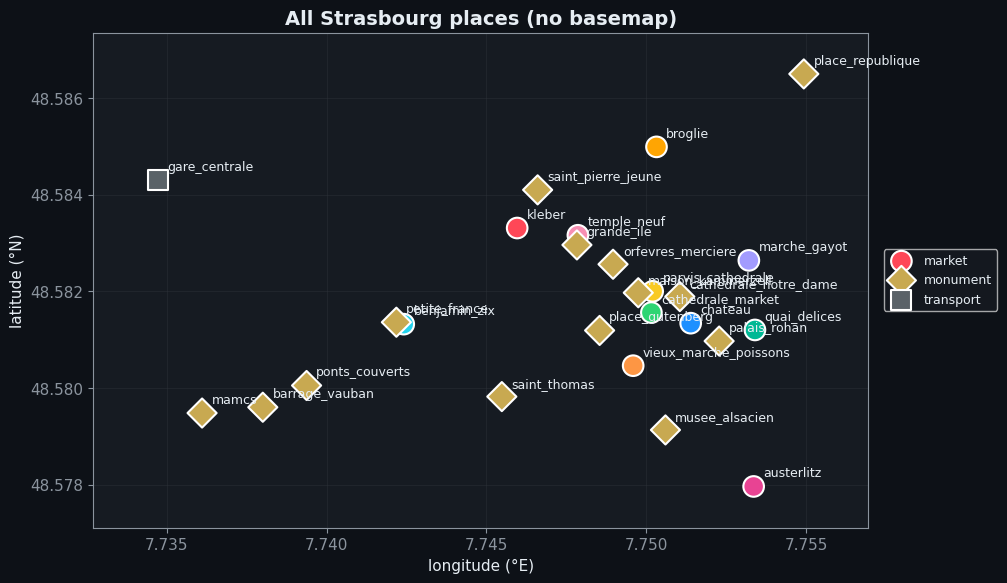

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
s.plot(places=list(s.MARKETS) + list(s.MONUMENTS) + list(s.TRANSPORT),
       label="key", ax=ax, title="All Strasbourg places (no basemap)")
s.place_legend_outside(ax)
plt.show()


## With OSM basemap (CartoDB DarkMatter)

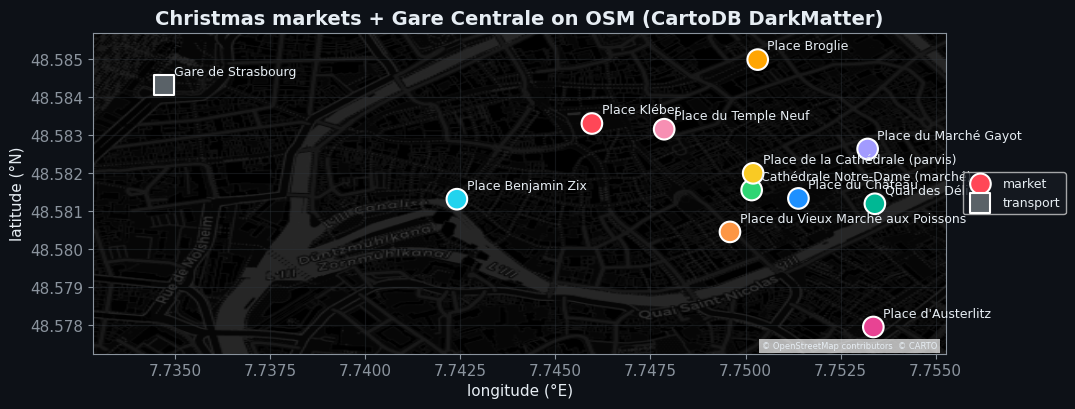

In [6]:
fig, ax = plt.subplots(figsize=(11, 9))
s.plot(places=list(s.MARKETS) + list(s.TRANSPORT),
       label="name", basemap=True, ax=ax,
       title="Christmas markets + Gare Centrale on OSM (CartoDB DarkMatter)")
s.place_legend_outside(ax)
plt.show()


## Drawing edges

`plot()` accepts `edges=[(a, b), ...]` where `a` and `b` are `Place`
objects, keys, or names. Edges are straight lines (great-circle is
indistinguishable at this scale).

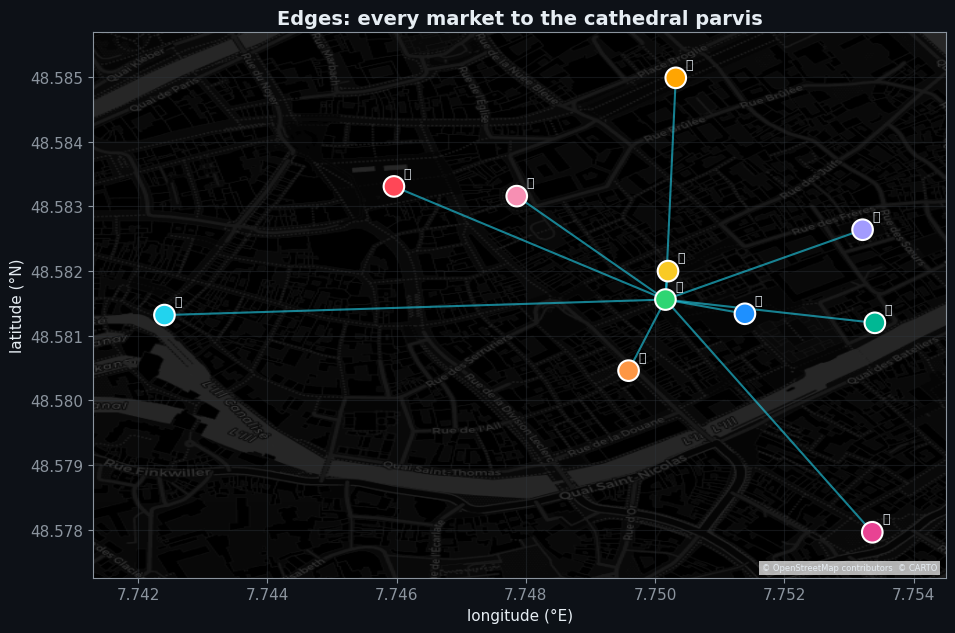

In [7]:
# Star-of-David edges from each market to the cathedral, just to show wiring.
edges = [(m, "cathedrale_market") for m in s.MARKETS if m.key != "cathedrale_market"]

fig, ax = plt.subplots(figsize=(11, 9))
s.plot(places=s.MARKETS, edges=edges,
       basemap=True, label="emoji", ax=ax,
       edge_color=theme.PALETTE["cyan"], edge_width=1.5, edge_alpha=0.6,
       title="Edges: every market to the cathedral parvis")
plt.show()


## TSP-five subset, with the optimal tour

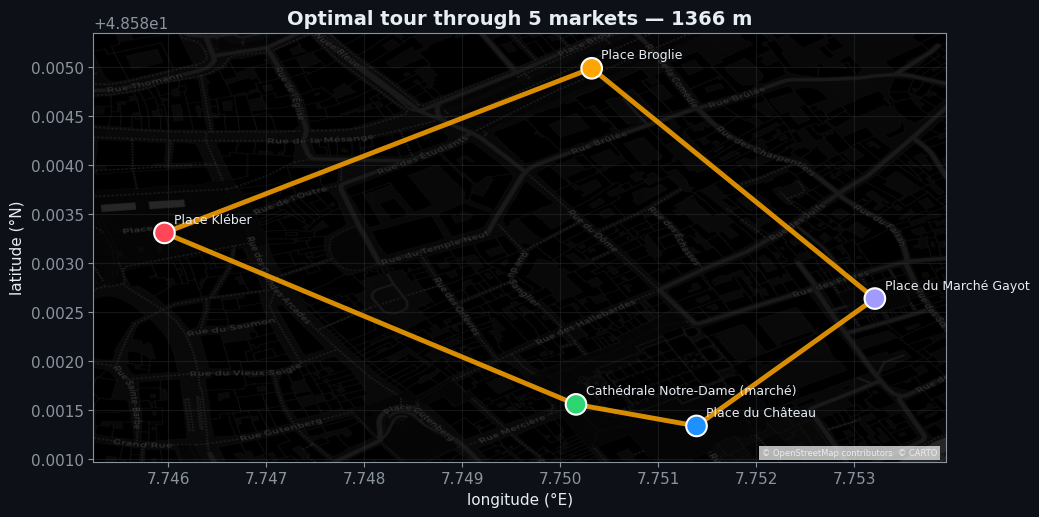

In [8]:
from strasbourg_markets_demo.tsp import TSPInstance, brute_force
inst = TSPInstance.strasbourg_markets()
tour, length = brute_force(inst)
five = s.tsp_five()
ordered = [five[i] for i in tour]
edges = list(zip(ordered, ordered[1:] + [ordered[0]]))

fig, ax = plt.subplots(figsize=(11, 9))
s.plot(places=five, edges=edges, basemap=True, label="name", ax=ax,
       edge_color=theme.PALETTE["yellow"], edge_width=3.5,
       title=f"Optimal tour through 5 markets — {length:.0f} m")
plt.show()


## Theme palette

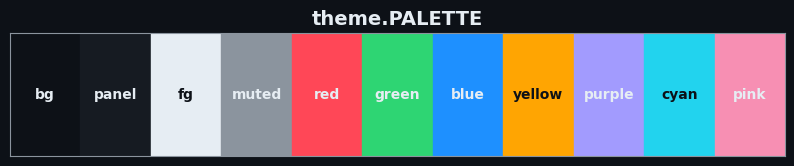

In [9]:
# The accent palette is shared with the per-place `color` attribute and
# matplotlib's `axes.prop_cycle`.
fig, ax = plt.subplots(figsize=(10, 1.6))
names = list(theme.PALETTE.keys())
for i, name in enumerate(names):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=theme.PALETTE[name]))
    ax.text(i + 0.5, 0.5, name, ha="center", va="center",
            color=theme.PALETTE["bg"] if name in {"yellow", "cyan", "fg"}
                  else theme.PALETTE["fg"], fontsize=10, fontweight="bold")
ax.set_xlim(0, len(names)); ax.set_ylim(0, 1)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("theme.PALETTE")
plt.show()


## API summary

```python
from strasbourg_markets_demo import strasbourg as s

s.MARKETS, s.MONUMENTS, s.TRANSPORT, s.ALL_PLACES   # tuples of Place
s.find(query)            # Place by key / name / alias
s.get(key)               # Place by exact key
s.by_kind("market")      # tuple[Place, ...] filtered

s.distance_m(a, b)                  # geodesic metres; a/b: Place | str | (lat, lon)
s.distance_matrix_m(places)         # ndarray (n, n)
s.coords_array(places)              # ndarray (n, 2) of (lat, lon)

s.tsp_five()                        # the TSP demo subset
s.vrp_default()                     # (depot, customers) for the VRP demo

s.plot(places=None, edges=None, *, ax=None,
       label="name", basemap=False, edge_color="#ffa502", ...)
```

The class form `Strasbourg()` is identical — both share the same
class-level data and methods.



---

<div style="text-align:center; padding:18px 0 6px 0"></div>

<div style="text-align:center; color:#8b949e; font-size:12px; padding-bottom:8px">Copyright © QPerfect &middot; Released under the MIT License &middot; <a href="https://qperfect.io">qperfect.io</a></div>